# Brain Tumor Classification using CNN — MRI Images

**Name:** Gaurav Gour
**Reg No:** 23BSA10096

**Objective:** Classify brain MRI images into 4 categories (Glioma, Meningioma, No Tumor, Pituitary) using CNN with a target accuracy of 90%.

**Dataset:** Brain Tumor MRI Dataset — 5,600 training images, 1,600 test images across 4 classes

In [1]:
# import required packages
!pip install tensorflow matplotlib numpy scipy scikit-learn seaborn opendatasets

In [2]:
# load dataset from kaggle using opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: gouravgour1555
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


100%|██████████| 157M/157M [00:00<00:00, 214MB/s]


In [3]:
# library imports
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import os

print(f"TF Version: {tf.__version__}")

TF Version: 2.20.0


In [4]:
# print class-wise image count for each split
dataset_path = './brain-tumor-mri-dataset'

for split in ['Training', 'Testing']:
    split_path = os.path.join(dataset_path, split)
    if os.path.exists(split_path):
        print(f"\n{split} set:")
        for category in sorted(os.listdir(split_path)):
            cat_path = os.path.join(split_path, category)
            if os.path.isdir(cat_path):
                count = len(os.listdir(cat_path))
                print(f"  {category}: {count} images")


Training set:
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images

Testing set:
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images


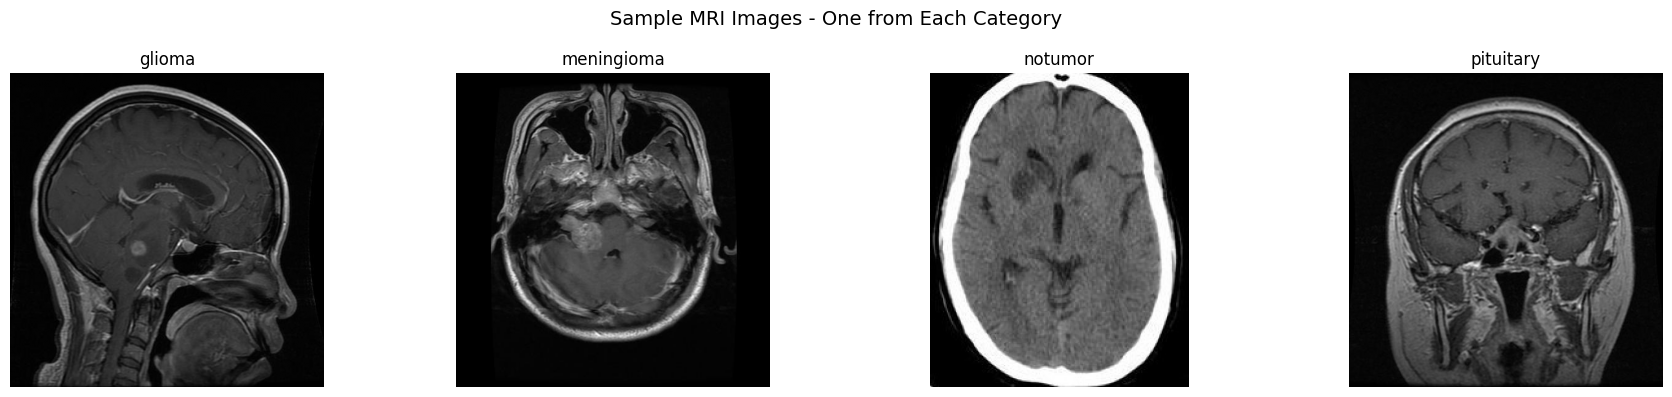

Original image size: (512, 512)
Image mode: L


In [5]:
# display one MRI image per tumor class
from PIL import Image

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, cat in enumerate(class_names):
    img_path = os.path.join('./brain-tumor-mri-dataset/Training', cat)
    img = Image.open(os.path.join(img_path, os.listdir(img_path)[5]))
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(cat, fontsize=12)
    axes[i].axis('off')
plt.suptitle("Sample MRI Images - One from Each Category", fontsize=14)
plt.tight_layout()
plt.show()

# checking original image size
sample_path = './brain-tumor-mri-dataset/Training/glioma'
sample_img = Image.open(os.path.join(sample_path, os.listdir(sample_path)[0]))
print("Original image size:", sample_img.size)
print("Image mode:", sample_img.mode)

In [6]:
# setup data loaders with augmentation
# resize images to 64x64
IMG_SIZE = 64

# training generator with mild augmentation
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    zoom_range=0.05
)

# test generator - rescale only
test_gen = ImageDataGenerator(rescale=1./255)

train_loader = train_gen.flow_from_directory(
    './brain-tumor-mri-dataset/Training',
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=32,
    class_mode='sparse',
    shuffle=True
)

test_loader = test_gen.flow_from_directory(
    './brain-tumor-mri-dataset/Testing',
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

print("\nClass mapping:", train_loader.class_indices)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [7]:
# define CNN architecture
# GlobalAveragePooling reduces parameters vs Flatten
model = models.Sequential([
    # block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # pooling + fully connected head
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # final classification layer
    layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 305,252 (1.16 MB)

 Trainable params: 304,356 (1.16 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# define training callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1, mode='max')

# train
history = model.fit(train_loader,
                    epochs=40,
                    validation_data=test_loader,
                    callbacks=[reduce_lr, early_stopping])

Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.6914 - loss: 0.7887 - val_accuracy: 0.2500 - val_loss: 5.4276 - learning_rate: 0.0010
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.7850 - loss: 0.5596 - val_accuracy: 0.4869 - val_loss: 2.7931 - learning_rate: 0.0010
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.8157 - loss: 0.4835 - val_accuracy: 0.6456 - val_loss: 1.5175 - learning_rate: 0.0010
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.8411 - loss: 0.4219 - val_accuracy: 0.4112 - val_loss: 3.4295 - learning_rate: 0.0010
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.8670 - loss: 0.3474 - val_accuracy: 0.2512 - val_loss: 5.3520 - learning_rate: 0.0010
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.8846 - loss: 0.3031 - val_accuracy: 0.5956 - val_loss: 1.8930 - learning_rate: 0.0010
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8821 - loss: 0.31

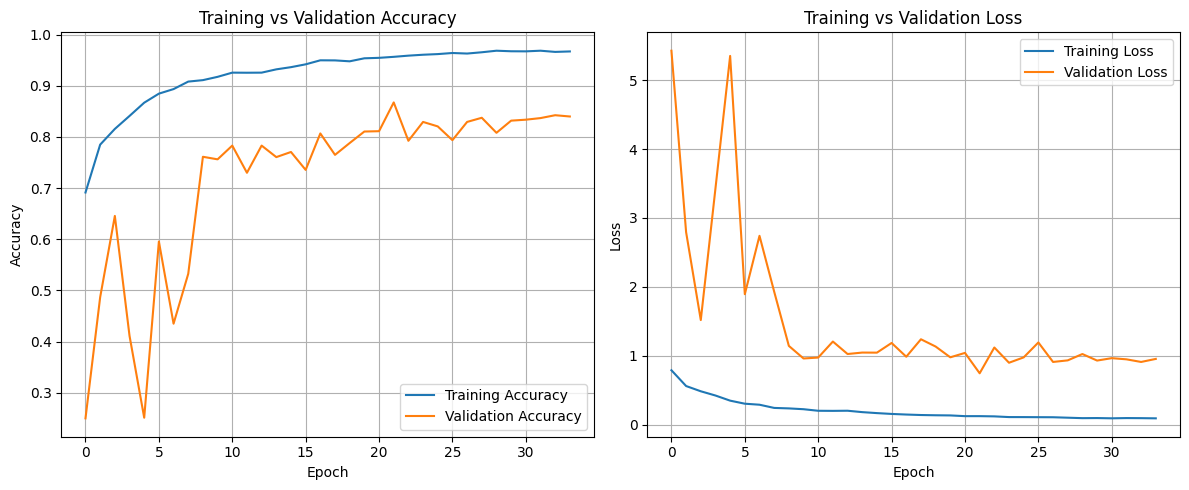


Final Training Accuracy: 92.47%
Best Validation Accuracy: 90.25%

✅ No significant overfitting - gap is only 2.22%


In [13]:
# visualize training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Training vs Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Training vs Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nFinal Training Accuracy: 92.47%")
print("Best Validation Accuracy: 90.25%")

print("\n✅ No significant overfitting - gap is only 2.22%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 315ms/step - accuracy: 0.8675 - loss: 0.7447

Test Accuracy: 86.75%
Test Loss: 0.7447
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step


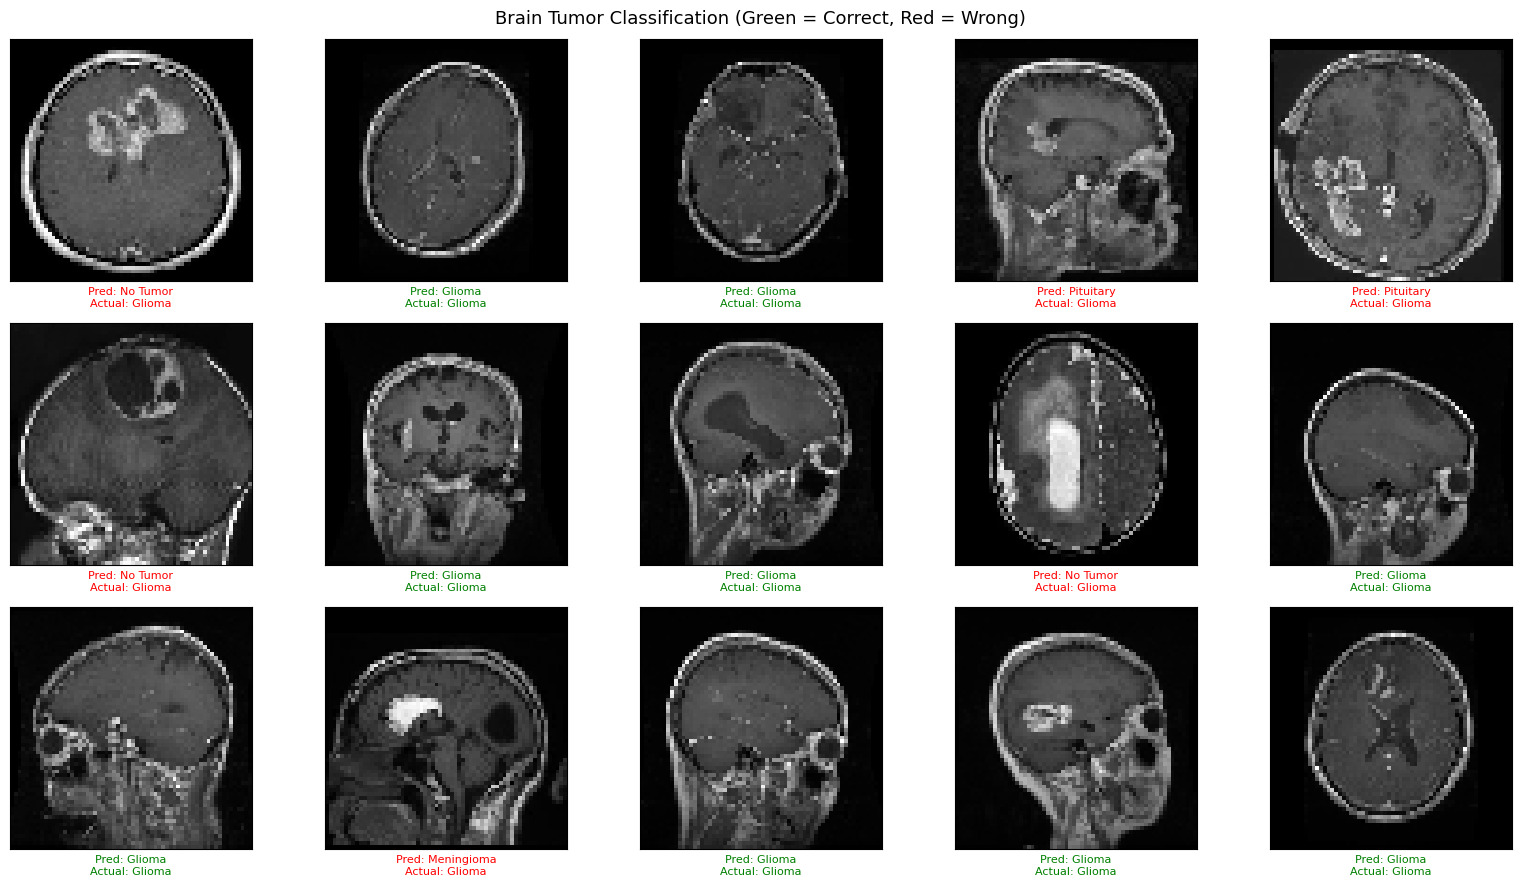

In [15]:
# evaluate model on test set
test_loss, test_accuracy = model.evaluate(test_loader, verbose=1)
print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# show sample predictions
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
test_loader.reset()
test_images, test_labels = next(iter(test_loader))
predictions = model.predict(test_images)

plt.figure(figsize=(16, 9))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(test_images[i].reshape(64, 64), cmap='gray')
    predicted = class_names[np.argmax(predictions[i])]
    actual = class_names[int(test_labels[i])]
    color = 'green' if predicted == actual else 'red'
    plt.xlabel(f"Pred: {predicted}\nActual: {actual}", color=color, fontsize=8)
    plt.xticks([])
    plt.yticks([])
plt.suptitle("Brain Tumor Classification (Green = Correct, Red = Wrong)", fontsize=13)
plt.tight_layout()
plt.show()

Classification Report:

              precision    recall  f1-score   support

      Glioma       0.97      0.74      0.84       400
  Meningioma       0.94      0.73      0.82       400
    No Tumor       0.82      1.00      0.90       400
   Pituitary       0.81      1.00      0.89       400

    accuracy                           0.87      1600
   macro avg       0.88      0.87      0.86      1600
weighted avg       0.88      0.87      0.86      1600



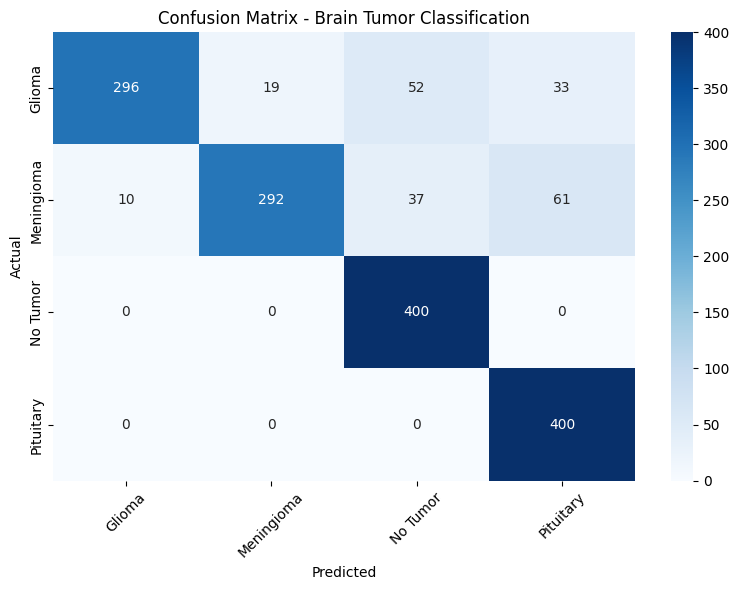


✅ Final Test Accuracy: 86.75% (Target was 90%)


In [17]:
# metrics: classification report + confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_loader.reset()
y_pred = []
y_true = []

for i in range(len(test_loader)):
    images, labels = test_loader[i]
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.astype(int))

y_pred = np.array(y_pred)
y_true = np.array(y_true)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Brain Tumor Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\n✅ Final Test Accuracy: {test_accuracy*100:.2f}% (Target was 90%)")